In [126]:
import pandas as pd
import numpy as  np
import matplotlib.pyplot as plt
import missingno as msn
import warnings

from IPython.core.pylabtools import figsize
from mistune.plugins.formatting import subscript

warnings.filterwarnings("ignore")

# Loading the  data

In [127]:
df=pd.read_csv("E:/PycharmProjects/data/archive/customer_churn_dataset-training-master.csv")

In [128]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [129]:
df.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [130]:
df.isnull().value_counts()

CustomerID  Age    Gender  Tenure  Usage Frequency  Support Calls  Payment Delay  Subscription Type  Contract Length  Total Spend  Last Interaction  Churn
False       False  False   False   False            False          False          False              False            False        False             False    440832
True        True   True    True    True             True           True           True               True             True         True              True          1
Name: count, dtype: int64

In [131]:
!pip install seaborn

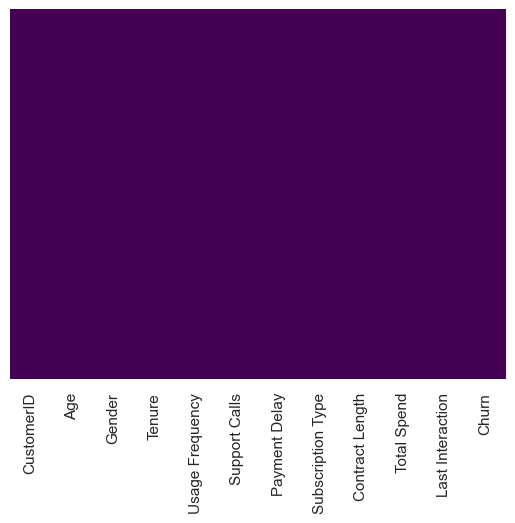

In [132]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.show()

In [133]:
df.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [134]:
# Returns the index of the row(s) where all columns are NaN
null_row_index = df[df.isnull().all(axis=1)].index
print(null_row_index)

Index([199295], dtype='int64')


In [135]:
# Drops rows where EVERY value is missing
df.dropna(how='all', inplace=True)

In [136]:
print(df.isnull().any(axis=1).value_counts())

False    440832
Name: count, dtype: int64


In [137]:
gender_map={'Male': 0, 'Female': 1}
df['Gender'] = df['Gender'].map(gender_map)

subscription_map={'Basic':0, 'Standard':1, 'Premium':2}
df['Subscription Type'] = df['Subscription Type'].map(subscription_map)

Contract_Length={'Annual':0, 'Quarterly':1, 'Monthly':2}
df['Contract Length'] = df['Contract Length'].map(Contract_Length)

### Train data

In [138]:
X = df.drop(columns=['Churn', 'CustomerID'])
Y = df['Churn'].values

In [139]:
X.drop(columns='Subscription Type', inplace=True)

In [140]:
X.isnull().any().value_counts()

False    9
Name: count, dtype: int64

In [141]:
X.isnull().sum()

Age                 0
Gender              0
Tenure              0
Usage Frequency     0
Support Calls       0
Payment Delay       0
Contract Length     0
Total Spend         0
Last Interaction    0
dtype: int64

In [142]:
DF = pd.read_csv("E:/PycharmProjects/data/archive/customer_churn_dataset-testing-master.csv")

### TestData

In [143]:
DF.isnull().any(axis=1).value_counts()

False    64374
Name: count, dtype: int64

In [144]:
DF["Gender"]=DF["Gender"].map(gender_map)
DF["Subscription Type"]=DF["Subscription Type"].map(subscription_map)
DF["Contract Length"]=DF["Contract Length"].map(Contract_Length)

In [145]:
x=DF.drop(columns=['Churn', 'CustomerID'])
y=DF['Churn'].values

In [146]:
x.dropna(how='all', inplace=True)

In [147]:
x.drop(columns='Subscription Type', inplace=True)

In [148]:
x.isnull().sum()

Age                 0
Gender              0
Tenure              0
Usage Frequency     0
Support Calls       0
Payment Delay       0
Contract Length     0
Total Spend         0
Last Interaction    0
dtype: int64

In [149]:
x.isnull().value_counts()

Age    Gender  Tenure  Usage Frequency  Support Calls  Payment Delay  Contract Length  Total Spend  Last Interaction
False  False   False   False            False          False          False            False        False               64374
Name: count, dtype: int64

# Visualization

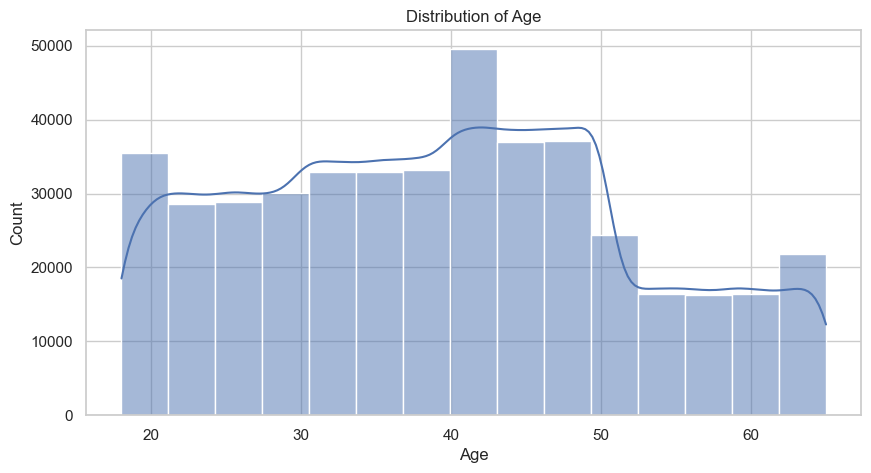

In [150]:
plt.figure(figsize=(10,5))
sns.histplot(df['Age'], bins=15, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.show()

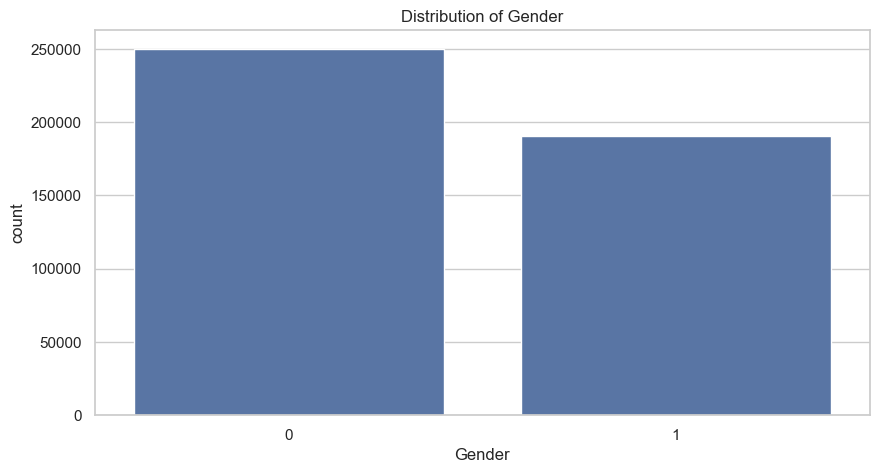

In [151]:
plt.figure(figsize=(10,5))
sns.countplot(x='Gender', data=df)
plt.title('Distribution of Gender')
plt.show()

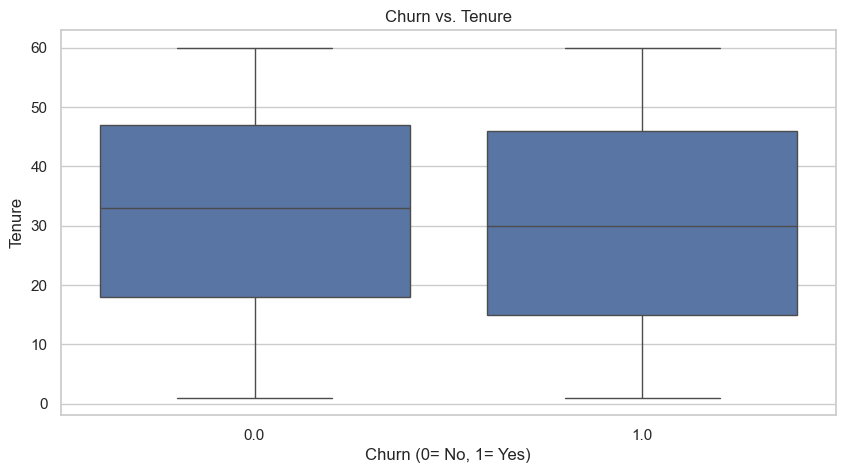

In [152]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Churn', y='Tenure', data=df)
plt.title('Churn vs. Tenure')
plt.xlabel('Churn (0= No, 1= Yes)')
plt.show()

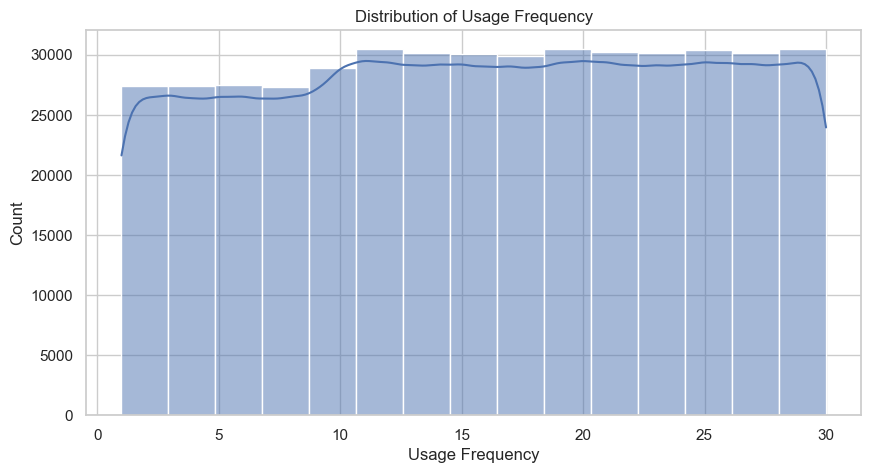

In [153]:
plt.figure(figsize=(10,5))
sns.histplot(df['Usage Frequency'], bins=15, kde=True)
plt.title('Distribution of Usage Frequency')
plt.xlabel('Usage Frequency')
plt.show()

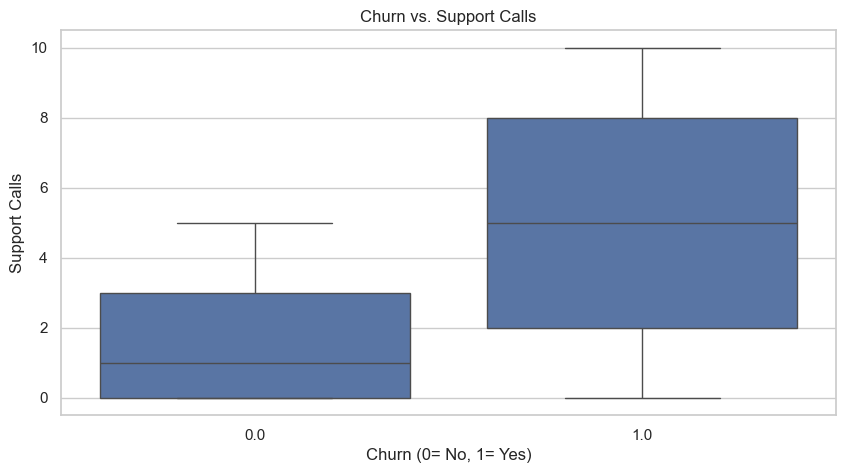

In [154]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Churn', y='Support Calls', data=df)
plt.title('Churn vs. Support Calls')
plt.xlabel('Churn (0= No, 1= Yes)')
plt.show()

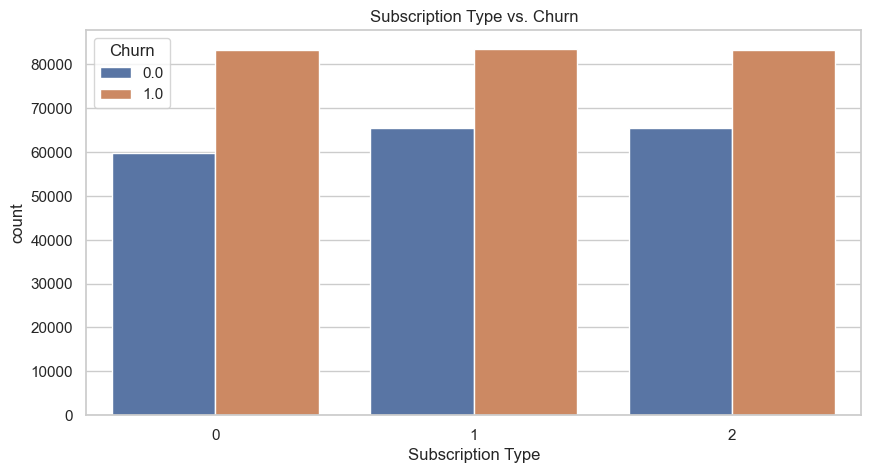

In [155]:
plt.figure(figsize=(10,5))
sns.countplot(x='Subscription Type', hue='Churn', data=df)
plt.title('Subscription Type vs. Churn')
plt.show()

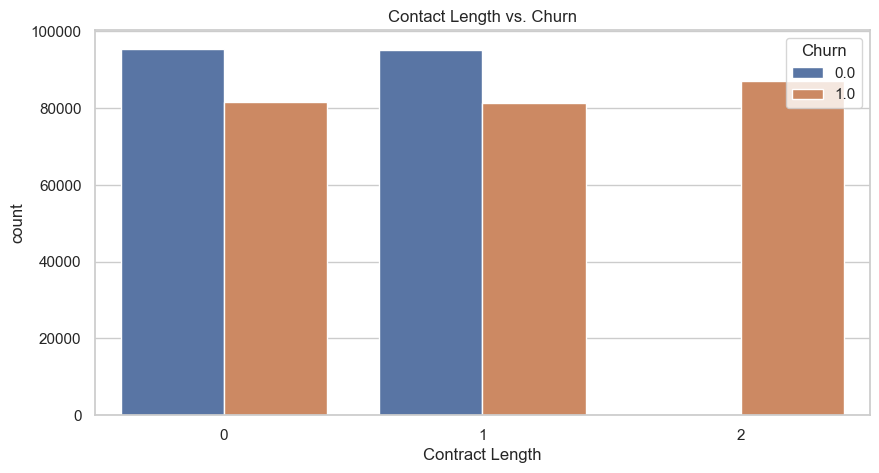

In [156]:
plt.figure(figsize=(10,5))
sns.countplot(x='Contract Length', hue='Churn', data=df)
plt.title('Contact Length vs. Churn')
plt.show()

In [157]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 440832 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  int64  
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  int64  
 8   Contract Length    440832 non-null  int64  
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), int64(3)
memory usage: 43.7 MB


In [158]:
df["Contract Length"].value_counts()

Contract Length
0    177198
1    176530
2     87104
Name: count, dtype: int64

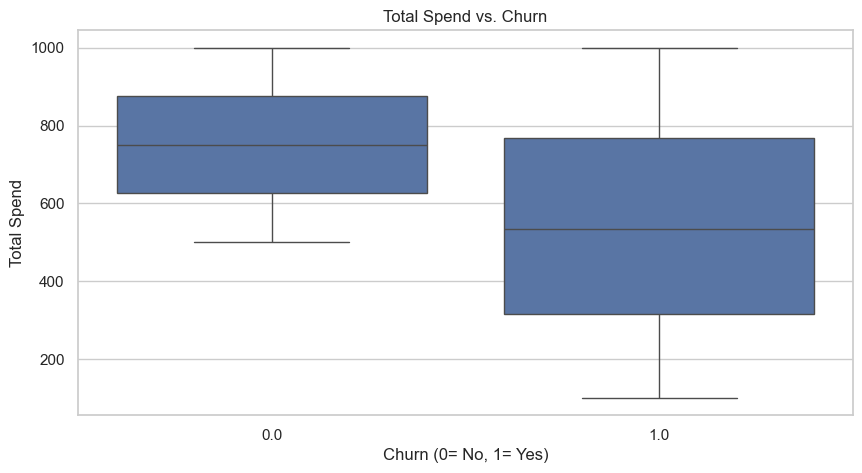

In [159]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Churn', y='Total Spend', data=df)
plt.title('Total Spend vs. Churn')
plt.xlabel('Churn (0= No, 1= Yes)')
plt.show()

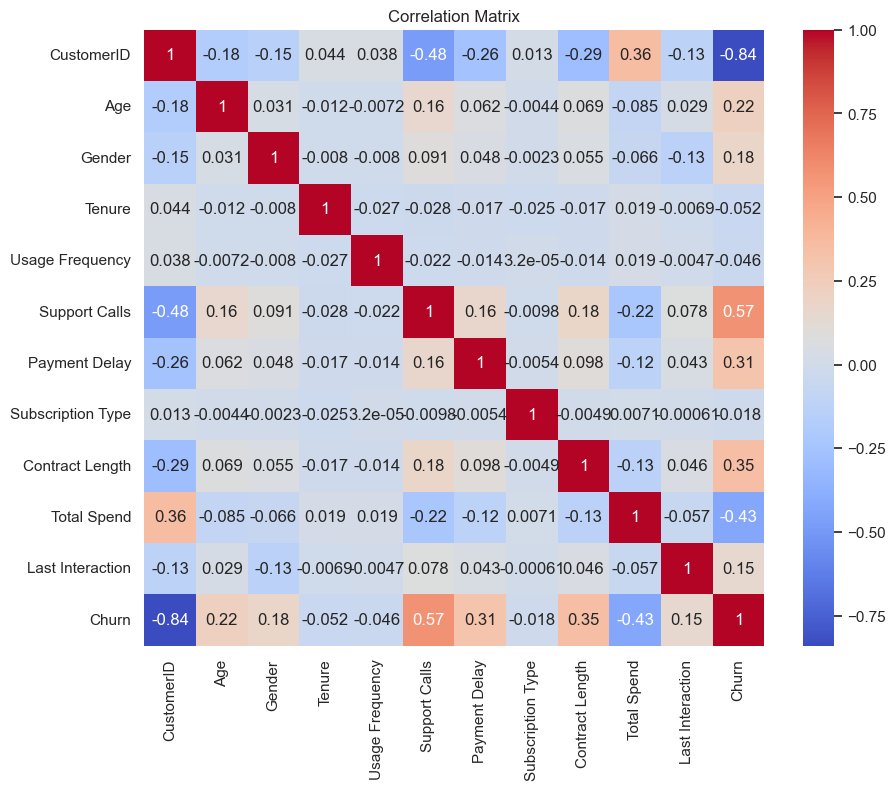

In [160]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [161]:
print(X.isnull().any(axis=1).value_counts())

False    440832
Name: count, dtype: int64


# Model & Implementation

In [162]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, f1_score


In [163]:
threshold_val=0.1

corr_mat=df.corr()
high_corr_feat=corr_mat.index[abs(corr_mat["Churn"]) > threshold_val].tolist()
high_corr_feat.remove("Churn")
print(high_corr_feat)
X1=df[high_corr_feat]
X=X1.drop(columns="CustomerID")
Y=df["Churn"]

['CustomerID', 'Age', 'Gender', 'Support Calls', 'Payment Delay', 'Contract Length', 'Total Spend', 'Last Interaction']


In [164]:
x1=DF[high_corr_feat]
x=x1.drop(columns="CustomerID")
y=DF["Churn"]

## Logistic Regression

In [165]:
X.isna().sum()

Age                 0
Gender              0
Support Calls       0
Payment Delay       0
Contract Length     0
Total Spend         0
Last Interaction    0
dtype: int64

In [166]:
m0=LogisticRegression(max_iter=1000, random_state=42)
m0.fit(X,Y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [167]:
X.isna().sum().value_counts()

0    7
Name: count, dtype: int64

In [168]:
LR_pred=m0.predict(x)

In [169]:
A0=accuracy_score(y, LR_pred)

In [170]:
A0

0.5782614098859788

## KNN

In [171]:
m2=KNeighborsClassifier(3)
m2.fit(X,Y)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [172]:
KNN_pred=m2.predict(x)
A2=accuracy_score(y, KNN_pred)

In [173]:
print("Classification Report: ", classification_report(y, KNN_pred))

Classification Report:                precision    recall  f1-score   support

           0       0.90      0.18      0.30     33881
           1       0.52      0.98      0.68     30493

    accuracy                           0.56     64374
   macro avg       0.71      0.58      0.49     64374
weighted avg       0.72      0.56      0.48     64374



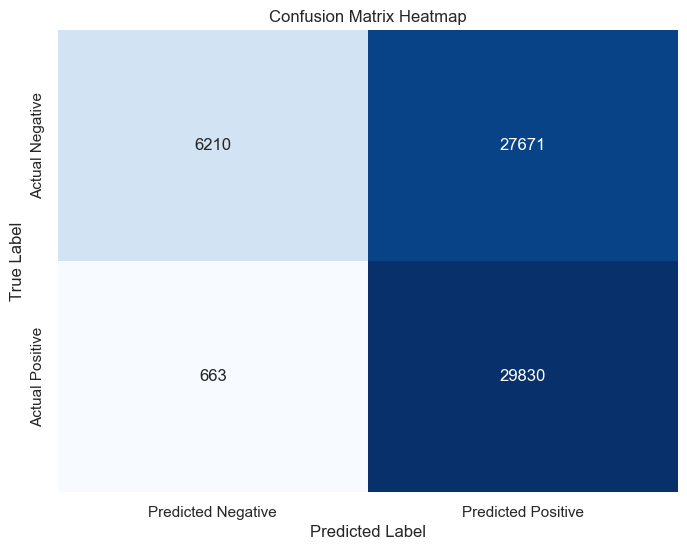

In [174]:
conf_matrix3 =confusion_matrix(y, KNN_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix3, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Predicted Negative", "Predicted Positive"],
            yticklabels=["Actual Negative", "Actual Positive"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

## SVM

In [175]:
from sklearn.svm import LinearSVC
m1=LinearSVC()
m1.fit(X, Y)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [176]:
SVD_pred=m1.predict(x)
print(accuracy_score(y, SVD_pred))
A1=accuracy_score(y, SVD_pred)

0.5800012427377512


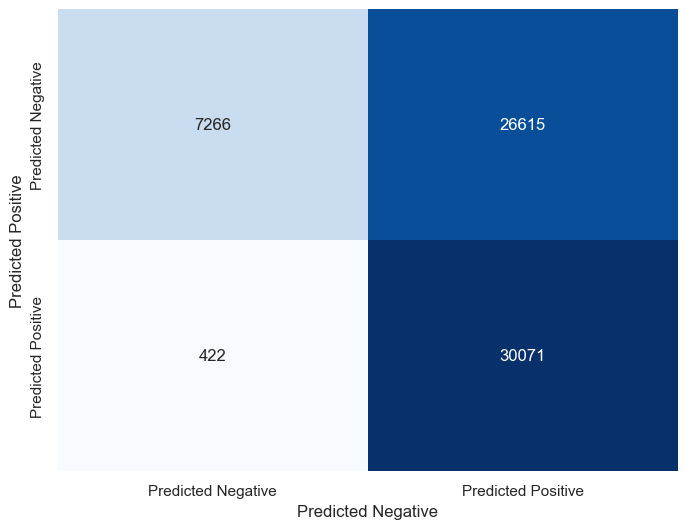

In [177]:
c1=confusion_matrix(y, SVD_pred)
plt.figure(figsize=(8,6))
sns.heatmap(c1, annot=True, fmt="d", cmap='Blues', cbar=False,
            xticklabels=["Predicted Negative", "Predicted Positive"],
            yticklabels=["Predicted Negative", "Predicted Positive"])
plt.xlabel("Predicted Negative")
plt.ylabel("Predicted Positive")
plt.show()

In [178]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [179]:
m0.fit(x_train, y_train)
p0=m0.predict(x_test)
a0=accuracy_score(y_test, p0)

In [180]:
m1.fit(x_train, y_train)
p1=m1.predict(x_test)
a1=accuracy_score(y_test, p1)

In [181]:
m2.fit(x_train, y_train)
p2=m2.predict(x_test)
a2=accuracy_score(y_test, p2)

In [182]:
m3 = DecisionTreeClassifier()
m3.fit(X, Y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [183]:
m3.fit(x_train, y_train)
P3=m3.predict(x_test)
a3=accuracy_score(y_test, P3)
a3

0.9941701543661461

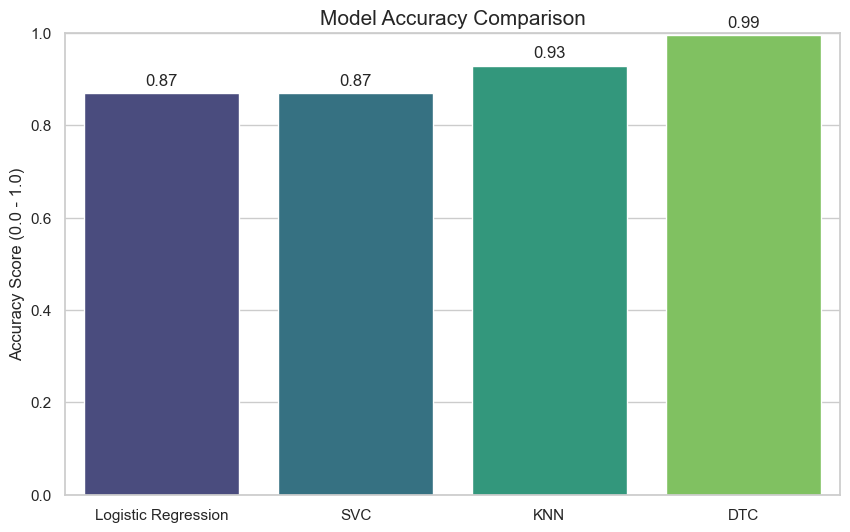

In [184]:
import seaborn as sns
import matplotlib.pyplot as plt


results = {
    'Logistic Regression': a0,
    'SVC': a1,
    'KNN': a2,
    'DTC': a3
}
# Set the style
sns.set_theme(style="whitegrid")

# Create the plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')

# Add labels and title
plt.title('Model Accuracy Comparison', fontsize=15)
plt.ylabel('Accuracy Score (0.0 - 1.0)')
plt.ylim(0, 1) # Set limit to 100% for perspective

# Add the exact score on top of each bar
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.show()

In [185]:
p3 = m3.predict(x)

In [186]:
A3 = accuracy_score(y, p3)
A3

0.5050952247801908

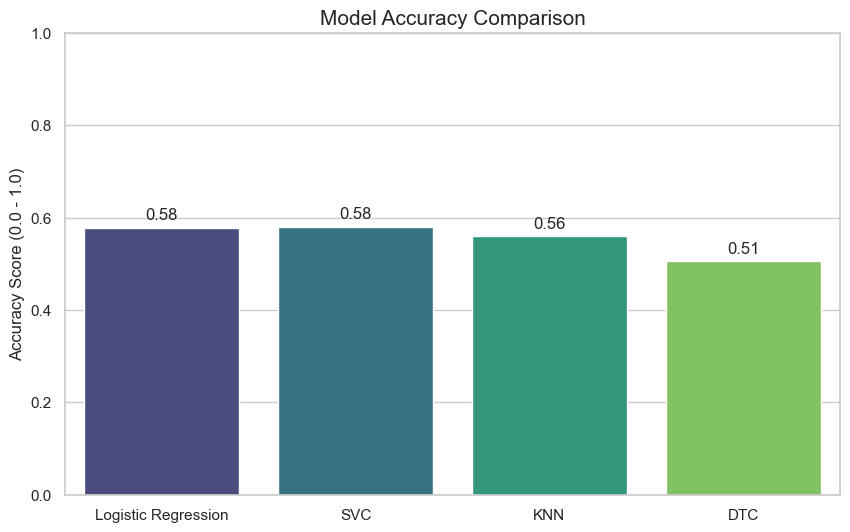

In [187]:
results = {
    'Logistic Regression':A0,
    'SVC': A1,
    'KNN': A2,
    'DTC': A3
}
# Set the style
sns.set_theme(style="whitegrid")

# Create the plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')

# Add labels and title
plt.title('Model Accuracy Comparison', fontsize=15)
plt.ylabel('Accuracy Score (0.0 - 1.0)')
plt.ylim(0, 1) # Set limit to 100% for perspective

# Add the exact score on top of each bar
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.show()

In [188]:
from sklearn.metrics._classification import f1_score
f1=f1_score(y,LR_pred)
f1

0.689096801529952

In [189]:
f2=f1_score(y,SVD_pred)
f2

0.6898679727916126

In [190]:
f3=f1_score(y, KNN_pred)
f3

0.6780007727799623

In [191]:
f4=f1_score(y,p3)
f4

0.6564956278909291

In [192]:
q1=f1_score(y_test,p1)
q2=f1_score(y_test,p1)
q3=f1_score(y_test,p2)
q4=f1_score(y_test,P3)
q1,q2,q3,q4

(0.883372070599937, 0.883372070599937, 0.9344454936522926, 0.9948736361278998)

In [193]:
X.shape, x.shape

((440832, 7), (64374, 7))